# Tests - experimentos exploratorios

Notebook al margen del codigo estable, pensado para pruebas rápidas que ayuden a tomar decisiones. No es parte del pipeline final.

## Fine-tuning de YOLO26 sobre KITTI

Medir el tiempo real por epoca y las metricas base (mAP, precision, recall) al hacer fine-tuning de yolo26n.pt sobre KITTI. Esto determina:

- Si el plan de comparar 2-4 configuraciones de hiperparametros con entrenamientos cortos (en vez de un model.tune() genetico completo, descartado por coste) cabe en el tiempo disponible.
- Un primer punto de referencia de mAP para saber si el fine-tuning va bien antes de lanzar el entrenamiento completo.

Incluye ademas dos verificaciones visuales (antes y despues de la primera prueba).

In [2]:
import time
from pathlib import Path

import yaml
from ultralytics import YOLO

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "pyproject.toml").exists(), f"Unexpected repo root: {REPO_ROOT}"

KITTI_DIR = REPO_ROOT / "data" / "kitti"
KITTI_YAML = KITTI_DIR / "kitti.yaml"
KITTI_YAML_LOCAL = KITTI_DIR / "kitti_local.yaml"

with open(KITTI_YAML, encoding="utf-8") as f:
    kitti_cfg = yaml.safe_load(f)

kitti_cfg["path"] = str(KITTI_DIR)  

with open(KITTI_YAML_LOCAL, "w", encoding="utf-8") as f:
    yaml.safe_dump(kitti_cfg, f, sort_keys=False, allow_unicode=True)


## Verificacion visual 1: efecto del resize cuadrado (antes de entrenar)

KITTI son imagenes panoramicas (1242x375). Con imgsz=640 y rect=False (el valor por defecto que usa esta prueba), Ultralytics redimensiona a un cuadrado 640x640, aplastando la imagen. Antes de decidir si activar rect=True, veamos con los ojos que efecto tiene esto sobre una imagen real y sus bounding boxes de KITTI.

Reutiliza `load_kitti_yolo_bboxes` de `src/xai_benchmark/data/kitti_dataset.py` (el paquete propio del repo) en vez de reescribir la logica de carga de etiquetas.

Imagen: 000002.png  1242x375  aspect ratio=3.31


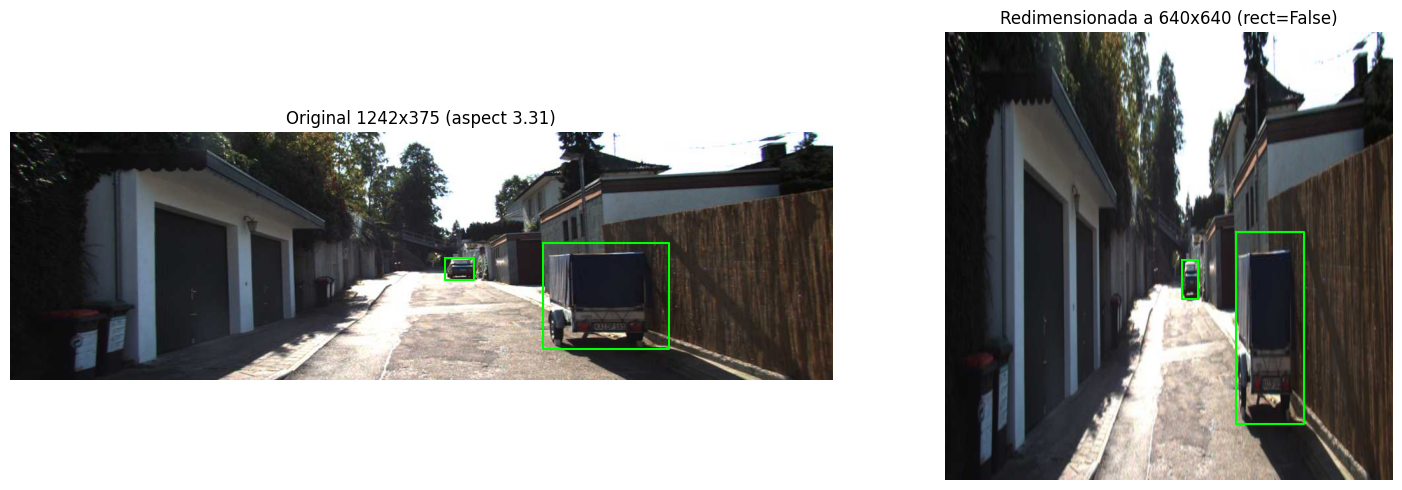

Objetos GT en esta imagen: 2
Compara la forma de coches entre ambas versiones: deformados (mas anchos/aplastados) en la cuadrada, es un argumento a favor de rect=True.


In [3]:
import sys

sys.path.insert(0, str(REPO_ROOT / "src"))

from PIL import Image
import matplotlib.pyplot as plt

from xai_benchmark.data.kitti_dataset import load_kitti_yolo_bboxes

train_img_dir = KITTI_DIR / "images" / "train"
train_label_dir = KITTI_DIR / "labels" / "train"

# Coge la primera imagen de train que tenga etiquetas no vacias
sample_img_path = None
for candidate in sorted(train_img_dir.glob("*.png"))[:30]:
    candidate_label = train_label_dir / f"{candidate.stem}.txt"
    if candidate_label.exists() and candidate_label.stat().st_size > 0:
        sample_img_path = candidate
        sample_label_path = candidate_label
        break
assert sample_img_path is not None, "No se encontro ninguna imagen con etiquetas en los primeros 30 candidatos"

orig = Image.open(sample_img_path)
orig_w, orig_h = orig.size
print(f"Imagen: {sample_img_path.name}  {orig_w}x{orig_h}  aspect ratio={orig_w / orig_h:.2f}")

bboxes_orig = load_kitti_yolo_bboxes(str(sample_label_path), img_height=orig_h, img_width=orig_w)

# Simula lo que hace imgsz=640 con rect=False: resize cuadrado, sin conservar aspect ratio
square = orig.resize((640, 640), Image.BILINEAR)
sx, sy = 640 / orig_w, 640 / orig_h
bboxes_square = [[(x * sx, y * sy) for (x, y) in bbox] for bbox in bboxes_orig]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(orig)
axes[0].set_title(f"Original {orig_w}x{orig_h} (aspect {orig_w / orig_h:.2f})")
axes[0].axis("off")
axes[1].imshow(square)
axes[1].set_title("Redimensionada a 640x640 (rect=False)")
axes[1].axis("off")

for ax, bboxes in [(axes[0], bboxes_orig), (axes[1], bboxes_square)]:
    for bbox in bboxes:
        xs = [p[0] for p in bbox] + [bbox[0][0]]
        ys = [p[1] for p in bbox] + [bbox[0][1]]
        ax.plot(xs, ys, "lime", linewidth=1.5)

plt.tight_layout()
plt.show()

print(f"Objetos GT en esta imagen: {len(bboxes_orig)}")
print("Compara la forma de coches entre ambas versiones: deformados (mas anchos/aplastados) en la cuadrada, es un argumento a favor de rect=True.")

## Configuracion de la prueba

- Modelo: yolo26n.pt (el mismo checkpoint de partida que se usara en el fine-tuning real).
- TEST_EPOCHS = 2 (el tiempo/epoca no depende de cuantas epocas totales se pidan, y con la GPU de 4GB como cuello de botella, no tiene sentido realizar muchas épocas completas solo para medir tiempo).
- workers=4 (bajado de 8 por defecto): la GPU ya es el cuello de botella, no la carga de datos: bajar workers alivia la RAM del sistema sin penalizar el tiempo.
- imgsz=640 (sin cambios; rect y batch se dejan como estan).
- Salida en results/runs/detect/tests_epoch_timing/ (gitignored, es reproducible).

## Prueba 1

In [ ]:
TEST_EPOCHS = 2  

model = YOLO(str(REPO_ROOT / "models" / "pretrained" / "yolo26n.pt"))

start = time.perf_counter()
results = model.train(
    data=str(KITTI_YAML_LOCAL),
    epochs=TEST_EPOCHS,
    imgsz=640,
    workers=4,  
    project=str(REPO_ROOT / "results" / "runs" / "detect"),
    name="tests_epoch_timing",
    exist_ok=True,
    device=0, 
)
elapsed = time.perf_counter() - start

print(f"Tiempo total ({TEST_EPOCHS} epocas): {elapsed:.1f} s")
print(f"Tiempo medio por epoca: {elapsed / TEST_EPOCHS:.1f} s")

New https://pypi.org/project/ultralytics/8.4.92 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.56  Python-3.11.14 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650 Ti with Max-Q Design, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\alber\OneDrive\Escritorio\Mster\TFM\TFM_codigo\data\kitti\kitti_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, 

In [ ]:
# Metricas de validacion final de esta prueba corta (no representativas, solo para tener una primera referencia)
metrics = results.results_dict
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

metrics/precision(B): 0.5870
metrics/recall(B): 0.2994
metrics/mAP50(B): 0.2935
metrics/mAP50-95(B): 0.1767
fitness: 0.1767


**Verificacion visual**: El mAP tras solo 2 épocas sera bajo (el modelo apenas ha empezado a converger), asi que el numero agregado por si solo no dice mucho. Antes de sacar conclusiones, miremos con los ojos si las cajas predichas al menos empiezan a solaparse con las reales en un par de imagenes de validacion, en vez de fiarnos solo de `results_dict`.

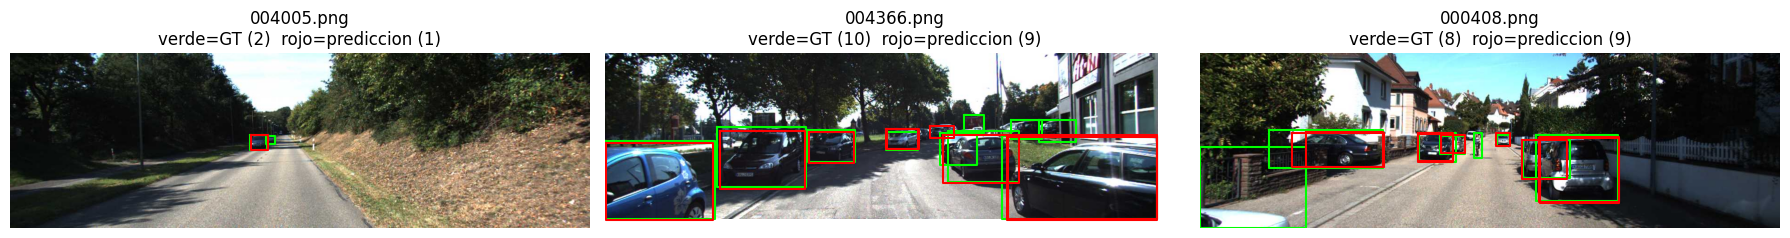

Con solo 2 epocas no se espera precision alta, pero las cajas rojas deberian empezar
a aparecer sobre coches/peatones reales, no en zonas sin objetos ni completamente al azar.


In [5]:
import random

from PIL import Image
import matplotlib.pyplot as plt

from xai_benchmark.data.kitti_dataset import load_kitti_yolo_bboxes

random.seed(0)

val_img_dir = KITTI_DIR / "images" / "val"
val_label_dir = KITTI_DIR / "labels" / "val"

sample_val_imgs = random.sample(sorted(val_img_dir.glob("*.png")), k=3)

fig, axes = plt.subplots(1, len(sample_val_imgs), figsize=(6 * len(sample_val_imgs), 5))

for ax, img_path in zip(axes, sample_val_imgs):
    label_path = val_label_dir / f"{img_path.stem}.txt"
    img = Image.open(img_path)
    w, h = img.size

    gt_bboxes = load_kitti_yolo_bboxes(str(label_path), img_height=h, img_width=w) if label_path.exists() else []
    pred = model.predict(str(img_path), conf=0.25, verbose=False)[0]
    pred_boxes_xyxy = [box.xyxy[0].tolist() for box in pred.boxes]

    ax.imshow(img)
    for bbox in gt_bboxes:
        xs = [p[0] for p in bbox] + [bbox[0][0]]
        ys = [p[1] for p in bbox] + [bbox[0][1]]
        ax.plot(xs, ys, "lime", linewidth=1.5)
    for (x1, y1, x2, y2) in pred_boxes_xyxy:
        ax.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], "red", linewidth=1.5)
    ax.set_title(f"{img_path.name}\nverde=GT ({len(gt_bboxes)})  rojo=prediccion ({len(pred_boxes_xyxy)})")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Con solo 2 epocas no se espera precision alta, pero las cajas rojas deberian empezar")
print("a aparecer sobre coches/peatones reales, no en zonas sin objetos ni completamente al azar.")

## Resultados Pruena 1

Con `batch`=16, `rect`=False y `cls_pw`=0.0

- Tiempo total: 4108.7 s
- Tiempo medio por epoca: 2054.3 s
- mAP50-95 (val): 0.177
- mAP50 (val):  0.294
- Precision / Recall (val):  0.587 / 0.299
- Por clase (mAP50-95): car 0.491, truck 0.327, van 0.214, pedestrian 0.164, tram 0.087, cyclist 0.094 (recall 0.111), misc 0.032 (recall 0), person_sitting 0.005 (recall 0) — refleja el desbalance de clases, confirma que cls_pw es una decisión real, no solo teórica.
- Verificacion visual 1 (aspect ratio): rect=True parece necesario por la distorsión que se genera en las imagenes.
- Verificacion visual 2 (predicciones): Las cajas están sobre objetos reales, no en zonas vacías. Es normal que sean imprecisas con solo dos etapas
- Observaciones generales: optimizer=auto eligió AdamW. AMP se desactivó por incompatibilidad con esta GPU.

## Prueba 2

Realizamos una segunda prueba que sigue el mismo esquema que la prueba de tiempos, cambiando tres hiperparámetros a la vez: rect=True (preserva el aspect ratio real de KITTI, en vez del resize cuadrado por defecto), batch=24 (con AMP desactivado en esta GPU el margen de VRAM es limitado, riesgo de CUDA out of memory, con batch=32 sucede CUDA out of memory) y cls_pw=0.5 (corrección parcial por desbalance de clases, frente al 0.0). Resultados guardados en un run nuevo (tests_hparam_rect_batch32_clspw05) para poder comparar mAP50-95, tiempo/época y desglose por clase contra la prueba 1 sin perder esta última.

In [3]:
TEST_EPOCHS = 2   

model_v2 = YOLO(str(REPO_ROOT / "models" / "pretrained" / "yolo26n.pt"))  

start = time.perf_counter()
results_v2 = model_v2.train(
    data=str(KITTI_YAML_LOCAL),
    epochs=TEST_EPOCHS,
    imgsz=640,
    rect=True,          
    batch=24,           
    cls_pw=0.5,         
    workers=4,
    project=str(REPO_ROOT / "results" / "runs" / "detect"),
    name="tests_hparam_rect_batch32_clspw05",  
    exist_ok=True,
    device=0,
)
elapsed = time.perf_counter() - start

print(f"Tiempo total ({TEST_EPOCHS} epocas): {elapsed:.1f} s")
print(f"Tiempo medio por epoca: {elapsed / TEST_EPOCHS:.1f} s")

New https://pypi.org/project/ultralytics/8.4.92 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.56  Python-3.11.14 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650 Ti with Max-Q Design, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=24, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\alber\OneDrive\Escritorio\Mster\TFM\TFM_codigo\data\kitti\kitti_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, 

In [4]:
metrics_v2 = results_v2.results_dict
for k, v in metrics_v2.items():
    print(f"{k}: {v:.4f}")

metrics/precision(B): 0.4610
metrics/recall(B): 0.2936
metrics/mAP50(B): 0.2821
metrics/mAP50-95(B): 0.1628
fitness: 0.1628


## Resultados Prueba 2

Con `batch`=24 y `rect`=True y `cls_pw`=0.5

- Tiempo total: 6413.6 s
- Tiempo medio por epoca: 3206.8 s
- mAP50-95 (val): 0.163
- mAP50 (val):  0.282
- Precision / Recall (val):  0.461 / 0.294
- Por clase (mAP50-95): car  0.433, truck 0.318, van 0.188, pedestrian 0.152, tram 0.116, cyclist 0.0614 (recall 0.136), misc 0.0325 (recall 0.024 ), person_sitting 0.00152 (recall 0)
- Observaciones generales: esta GPU tiene 4096 MiB físicos, y en ambas
pruebas GPU_mem los supera (4.77 GB y 6.85-6.95 GB respectivamente). En vez de lanzar un error al superar la VRAM,
un driver de NVIDIA desborda a RAM del sistema para evitar el crash, a costa de mucha
velocidad, sin avisar. El culpable es batch=24 en sí mismo
(más activaciones simultáneas en memoria), agravado por no tener AMP disponible en esta GPU.

Tras estos dos primeras pruebas, se descarta subir de 16 en esta GPU — 24 ya desborda VRAM de
forma relevante (~2.9 GB) y 32 hace `out of memory` directo. Los siguientes tests y el fine-tuning
final se quedan en batch=16.

Realizamos dos pruebas más ya que el mAP no es comparable todavía por cambiar `rect`, `batch`, y `cls_pw` a la vez. No sabemos cual causo la bajada de mAP. Además, se supone que cls_pw > 0.0 ayuda a solucionar el desbalanceo de clases pero en casi todas las clases empeoraron en la segunda prueba. Con solo 2 épocas y la confusión de memoria de por medio, no se puede concluir nada todavía sobre si
`rect`/`cls_pw` ayudan o no.

## Prueba 3

In [5]:
TEST_EPOCHS = 2  

model_rect = YOLO(str(REPO_ROOT / "models" / "pretrained" / "yolo26n.pt"))  # fresh weights

start = time.perf_counter()
results_rect = model_rect.train(
    data=str(KITTI_YAML_LOCAL),
    epochs=TEST_EPOCHS,
    imgsz=640,
    rect=True,   
    batch=16,    
    workers=4,
    project=str(REPO_ROOT / "results" / "runs" / "detect"),
    name="tests_hparam_rect_only",  
    exist_ok=True,
    device=0,
)
elapsed = time.perf_counter() - start

print(f"Tiempo total ({TEST_EPOCHS} epocas): {elapsed:.1f} s")
print(f"Tiempo medio por epoca: {elapsed / TEST_EPOCHS:.1f} s")

New https://pypi.org/project/ultralytics/8.4.92 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.56  Python-3.11.14 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650 Ti with Max-Q Design, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\alber\OneDrive\Escritorio\Mster\TFM\TFM_codigo\data\kitti\kitti_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, 

In [6]:
metrics_rect = results_rect.results_dict
for k, v in metrics_rect.items():
    print(f"{k}: {v:.4f}")

metrics/precision(B): 0.4444
metrics/recall(B): 0.2941
metrics/mAP50(B): 0.2642
metrics/mAP50-95(B): 0.1573
fitness: 0.1573


## Resultados Prueba 3

Con `batch`=16, `rect`=True y `cls_pw`=0.0 (por defecto)

- Tiempo total: 5481.4 s
- Tiempo medio por epoca: 2740.7 s
- mAP50-95 (val): 0.157
- mAP50 (val): 0.264
- Precision / Recall (val): 0.444 / 0.294
- Por clase (mAP50-95): car 0.458, truck 0.280, van 0.183, pedestrian 0.155, tram 0.0826 (recall 0.179), cyclist 0.0765 (recall 0.153), misc 0.0226 (recall 0.024), person_sitting 0.000812 (recall 0)
- Observaciones generales: aislado de `batch`/`cls_pw` (ambos iguales que la Prueba 1), `rect=True` por si solo ya tarda mas (2740.7 s/epoca vs. 2054.3 s/epoca de la Prueba 1, +33%), pese a que el uso de VRAM es casi identico al de la Prueba 1 descarto el desbordamiento a RAM del sistema como causa esta vez. Posibilidad de que la lentitud viene de `rect=True` en si mismo o sea por algo ajeno. Ademas, casi todas las clases empeoran frente a la Prueba 1 (mAP50-95 0.157 vs. 0.177, precision 0.444 vs. 0.587), esto contradice la hipotesis inicial de que `rect=True` deberia ayudar dado el aspect ratio de KITTI. 
- **Hallazgo clave**: Tras investigar la librería de Ultralytics me doy cuenta de que activar `rect=True` desactiva `mosaic`, `mixup` y `cutmix` (metodos de data augmentation del modelo que se aplican por defecto) por completo. Como conclusión saco que esto provoca un empeoramiento de mAP. Por ello, decido aplicar `rect=False` en el fine-tuning final.

## Prueba 4

In [3]:
TEST_EPOCHS = 2

model_clspw = YOLO(str(REPO_ROOT / "models" / "pretrained" / "yolo26n.pt"))

start = time.perf_counter()
results_clspw = model_clspw.train(
    data=str(KITTI_YAML_LOCAL),
    epochs=TEST_EPOCHS,
    imgsz=640,
    cls_pw=0.5,  
    batch=16,    
    workers=4,
    project=str(REPO_ROOT / "results" / "runs" / "detect"),
    name="tests_hparam_clspw_only", 
    exist_ok=True,
    device=0,
)
elapsed = time.perf_counter() - start

print(f"Tiempo total ({TEST_EPOCHS} epocas): {elapsed:.1f} s")
print(f"Tiempo medio por epoca: {elapsed / TEST_EPOCHS:.1f} s")

New https://pypi.org/project/ultralytics/8.4.93 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.56  Python-3.11.14 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650 Ti with Max-Q Design, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\alber\OneDrive\Escritorio\Mster\TFM\TFM_codigo\data\kitti\kitti_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, 

In [4]:
metrics_clspw = results_clspw.results_dict
for k, v in metrics_clspw.items():
    print(f"{k}: {v:.4f}")

metrics/precision(B): 0.4921
metrics/recall(B): 0.3206
metrics/mAP50(B): 0.3275
metrics/mAP50-95(B): 0.1956
fitness: 0.1956


## Resultados Prueba 4

Con `batch`=16, `rect`=False (por defecto) y `cls_pw`=0.5

- Tiempo total: 3527.7 s
- Tiempo medio por epoca: 1763.8 s
- mAP50-95 (val): 0.196
- mAP50 (val): 0.328
- Precision / Recall (val): 0.492 / 0.321
- Por clase (mAP50-95): car 0.458, van 0.230, truck 0.369, pedestrian 0.167, person_sitting 0.0777 (recall 0), tram 0.123, cyclist 0.0905 (recall 0.161), misc 0.0493 (recall 0.0288)
- Observaciones generales: aislado de `batch`/`rect` (ambos iguales que la Prueba 1), `cls_pw=0.5` por si solo mejora el mAP50-95 global (0.196 vs. 0.177 de la Prueba 1, +11%) y sobre todo las clases minoritarias -- destaca `person_sitting`, que pasa de mAP50-95=0.005 a 0.0777 (aunque el recall puntual siga marcando 0, la curva precision-recall mejora claramente), y tambien mejoran `truck`, `van`, `tram` y `misc`. A cambio, `car` (la clase mayoritaria) empeora un poco (0.458 vs. 0.491) y la precision global baja (0.492 vs. 0.587), algo esperado por re-ponderar la perdida por desbalance de clases.

## Prueba 5

In [ ]:
TEST_EPOCHS = 2 

model_freeze = YOLO(str(REPO_ROOT / "models" / "pretrained" / "yolo26n.pt"))  # fresh weights

start = time.perf_counter()
results_freeze = model_freeze.train(
    data=str(KITTI_YAML_LOCAL),
    epochs=TEST_EPOCHS,
    imgsz=640,
    batch=16,     
    cls_pw=0.5,  
    freeze=10,   
    workers=4,
    project=str(REPO_ROOT / "results" / "runs" / "detect"),
    name="tests_hparam_freeze_only",  
    exist_ok=True,
    device=0,
)
elapsed = time.perf_counter() - start

print(f"Tiempo total ({TEST_EPOCHS} epocas): {elapsed:.1f} s")
print(f"Tiempo medio por epoca: {elapsed / TEST_EPOCHS:.1f} s")

New https://pypi.org/project/ultralytics/8.4.94 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.56  Python-3.11.14 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650 Ti with Max-Q Design, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\alber\OneDrive\Escritorio\Mster\TFM\TFM_codigo\data\kitti\kitti_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mo

In [3]:
metrics_freeze = results_freeze.results_dict
for k, v in metrics_freeze.items():
    print(f"{k}: {v:.4f}")

metrics/precision(B): 0.5154
metrics/recall(B): 0.2856
metrics/mAP50(B): 0.3162
metrics/mAP50-95(B): 0.1878
fitness: 0.1878


## Resultados Prueba 5

Con `batch`=16, `rect`=False, `cls_pw`=0.5 y `freeze`=10.

- Tiempo total: 4555.0 s
- Tiempo medio por epoca: 2277.5 s
- mAP50-95 (val): 0.188
- mAP50 (val): 0.316
- Precision / Recall (val): 0.515 / 0.286
- Por clase (mAP50-95): car 0.436, truck 0.354, van 0.192, pedestrian 0.171, person_sitting 0.117, tram 0.105, cyclist 0.0742, misc 0.0522
- Observaciones generales: `GPU_mem` baja notablemente (2.67-2.76 GB, frente a 4.77-4.78 GB de la Prueba 4) -- congelar 10 capas reduce el estado de gradientes/optimizador que hay que guardar. Sin embargo, el tiempo por epoca sale mas lento (2277.5 s vs. 1763.8 s de la Prueba 4, +29%) pese a tener menos parametros entrenables -- contraintuitivo pero no generalizable por ser una simple prueba corta. En metricas: mAP50-95 baja ligeramente (0.188 vs. 0.196 de la Prueba 4), precision algo mejor (0.515 vs. 0.492), recall peor (0.286 vs. 0.321); por clase, mejora notablemente person_sitting (0.117 vs. 0.0777) pero empeoran car, van, cyclist y tram. Con solo 2 epocas de proxy es esperable que el beneficio de `freeze=10` (menos sobreajuste con datos limitados) no se aprecie del todo, ese beneficio se espera mas a largo plazo, no en una prueba tan corta.

## Sanity check: Step 0 (yolo_head.py)

Valida `get_one2many_predictions` (src/xai_benchmark/detection/yolo_head.py)
contra el checkpoint de la Prueba 1 (mejor resultado hasta ahora: mAP50-95=0.177),
comparando su salida contra la del camino oficial `model.predict()` sobre las mismas imagenes.

In [ ]:
import sys
from pathlib import Path

import cv2
import torch
from ultralytics import YOLO

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "pyproject.toml").exists(), f"Unexpected repo root: {REPO_ROOT}"

sys.path.insert(0, str(REPO_ROOT / "src"))
from xai_benchmark.detection.yolo_head import get_one2many_predictions
from xai_benchmark.data.kitti_dataset import load_kitti_yolo_bboxes, KITTI_CLASSES

CHECKPOINT = REPO_ROOT / "results" / "runs" / "detect" / "finetune_stage2_unfrozen" / "weights" / "best.pt"
assert CHECKPOINT.exists(), f"Checkpoint no encontrado: {CHECKPOINT}"

# Dos instancias independientes del MISMO checkpoint -- necesario porque .predict()
# fusiona el modelo; si reutilizaramos el mismo objeto para
# ambas cosas, get_one2many_predictions recibiria un modelo ya fusionado y devolveria
# detecciones vacias en silencio (Explicación en yolo_head.py).
model_dense = YOLO(str(CHECKPOINT))  # SOLO se usa con get_one2many_predictions, nunca .predict()/.val()
model_ref = YOLO(str(CHECKPOINT))    # SOLO se usa para la prediccion oficial de referencia

print("model_dense.end2end:", model_dense.model.end2end)

model_dense.end2end: True


Muestra de imagenes de validacion con GT

In [2]:
import random

random.seed(0)

val_img_dir = REPO_ROOT / "data" / "kitti" / "images" / "val"
val_label_dir = REPO_ROOT / "data" / "kitti" / "labels" / "val"

sample_paths = [val_img_dir / name for name in
                 ["007151.png", "005648.png", "000791.png", "005876.png"]]
images_bgr = [cv2.imread(str(p)) for p in sample_paths]

gt_boxes_per_image = []
for p in sample_paths:
    label_path = val_label_dir / f"{p.stem}.txt"
    h, w = cv2.imread(str(p)).shape[:2]
    gt_boxes_per_image.append(load_kitti_yolo_bboxes(str(label_path), img_height=h, img_width=w) if label_path.exists() else [])

print("Imagenes muestreadas:", [p.name for p in sample_paths])
print("Nº de objetos GT por imagen:", [len(b) for b in gt_boxes_per_image])

Imagenes muestreadas: ['007151.png', '005648.png', '000791.png', '005876.png']
Nº de objetos GT por imagen: [11, 13, 14, 6]


In [3]:
ref_results = model_ref.predict(images_bgr, conf=0.25, verbose=False)

imgs_tensor = model_ref.predictor.preprocess(images_bgr)

orig_shapes = [img.shape[:2] for img in images_bgr]  # (alto, ancho) de cada imagen original, mismo orden que images_bgr

dense_detections = get_one2many_predictions(model_dense, imgs_tensor, orig_shapes, conf_thres=0.25, iou_thres=0.5)

print("model_dense.end2end despues de llamar a la funcion:", model_dense.model.end2end)
print("Nº de detecciones (dense, tras nuestro NMS) por imagen:", [len(d.boxes) for d in dense_detections])
print("Nº de detecciones (oficial, model.predict()) por imagen:", [len(r.boxes) for r in ref_results])

for d in dense_detections:
    if len(d.class_probs):
        suma_ejemplo = d.class_probs[0].sum().item()
        print("Suma de probabilidades de la primera caja (debe NO ser ~1.0):", round(suma_ejemplo, 3))
        break

model_dense.end2end despues de llamar a la funcion: True
Nº de detecciones (dense, tras nuestro NMS) por imagen: [10, 12, 14, 5]
Nº de detecciones (oficial, model.predict()) por imagen: [11, 12, 17, 7]
Suma de probabilidades de la primera caja (debe NO ser ~1.0): 0.934


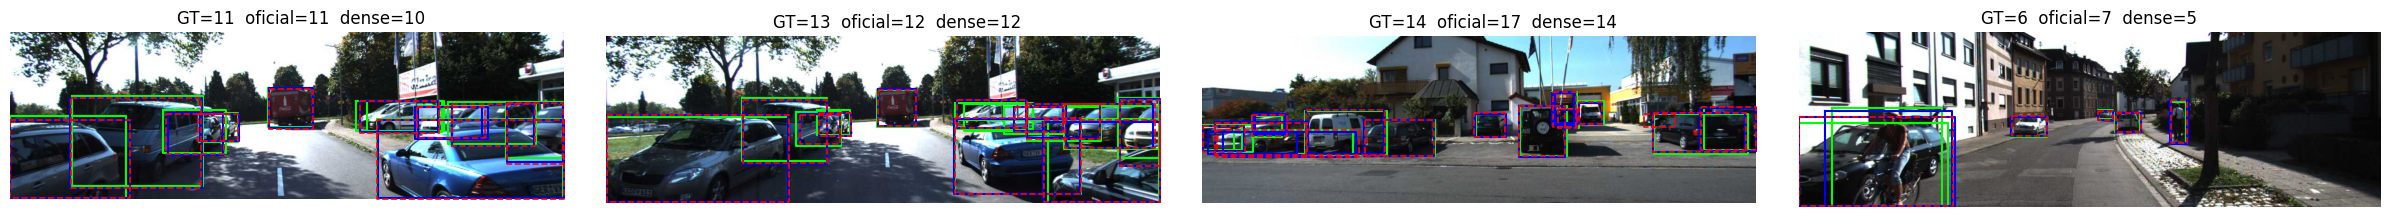

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(sample_paths), figsize=(6 * len(sample_paths), 5))

for ax, img_bgr, gt_boxes, dense, ref in zip(axes, images_bgr, gt_boxes_per_image, dense_detections, ref_results):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    for bbox in gt_boxes:  # verde = GT
        xs = [p[0] for p in bbox] + [bbox[0][0]]
        ys = [p[1] for p in bbox] + [bbox[0][1]]
        ax.plot(xs, ys, "lime", linewidth=1.5)

    for x1, y1, x2, y2 in ref.boxes.xyxy.tolist():  # azul = oficial (model.predict(), one2one)
        ax.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], "blue", linewidth=1.5)

    for x1, y1, x2, y2 in dense.boxes.tolist():  # rojo = nuestro Step 0 (one2many + NMS propio)
        ax.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], "red", linewidth=1.2, linestyle="--")

    ax.set_title(f"GT={len(gt_boxes)}  oficial={len(ref.boxes)}  dense={len(dense.boxes)}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
for d in dense_detections:
    print("Clases predichas (dense):", d.class_probs.argmax(-1).tolist())

Clases predichas (dense): [0, 0, 1, 2, 0, 0, 1, 0, 0, 0]
Clases predichas (dense): [0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0]
Clases predichas (dense): [0, 0, 1, 0, 0, 0, 1, 7, 2, 0, 7, 7, 0, 0]
Clases predichas (dense): [0, 0, 0, 3, 0]


In [6]:
print("Clases predichas (oficial, model.predict()):", [r.boxes.cls.tolist() for r in ref_results])

Clases predichas (oficial, model.predict()): [[2.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 2.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 7.0, 2.0, 0.0, 7.0, 7.0, 0.0, 7.0, 2.0, 2.0], [0.0, 0.0, 0.0, 5.0, 0.0, 3.0, 3.0]]


In [7]:
for p in sample_paths:
    label_path = val_label_dir / f"{p.stem}.txt"
    with open(label_path, encoding="utf-8") as f:
        clases_gt = [int(line.split()[0]) for line in f if line.strip()]
    print(p.name, "clases GT:", clases_gt)

007151.png clases GT: [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 2]
005648.png clases GT: [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 2]
000791.png clases GT: [1, 0, 0, 0, 0, 0, 1, 0, 2, 7, 0, 0, 7, 7]
005876.png clases GT: [0, 5, 3, 0, 0, 0]
